# AI-Based Job & Skill Recommendation — SkillBridge AI
### Colab Notebook | Dataset: `job_recommendation_dataset.csv`
### Models: TF-IDF + Cosine + Jaccard  ·  Sentence-BERT + Cosine + Jaccard

**Dataset:** 50,000 job postings across 7 industry categories  
**Target:** Predict job `Industry` from Required Skills (proxy recommendation evaluation)  
**Models:**  
- **Primary:** TF-IDF + Cosine Similarity + Jaccard Skill Overlap  
- **Improved:** Sentence-BERT + Cosine Similarity + Jaccard Skill Overlap  

---
> **Evaluation strategy:** A *proxy evaluation* is used because the dataset has no explicit user-job labels:  
> each test job is queried using its **first 2 Required Skills**, then we measure  
> whether the predicted `Industry` matches the true `Industry`.  
> **Target accuracy: 82–85 %**

In [ ]:
# ============================================================
# Cell 1 — Install Dependencies
# ============================================================
!pip -q install sentence-transformers scikit-learn pandas numpy matplotlib seaborn
print("Dependencies installed!")

Dependencies installed!


In [ ]:
# ============================================================
# Cell 2 — Imports
# ============================================================
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

print("All imports successful!")

All imports successful!


In [ ]:
# ============================================================
# Cell 3 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# Cell 4 — Load Dataset  (job_recommendation_dataset.csv)
# ============================================================
# ── UPDATE THIS PATH to match your Google Drive location ──
DATA_PATH = "/content/drive/MyDrive/Team 8 (Ai based Job & Skill Recommendation)/Datasets/job_recommendation_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded!  Shape: {df.shape}")
print(f"\n Columns : {df.columns.tolist()}")
print(f"\n Industry distribution:")
display(df["Industry"].value_counts().rename("Count").to_frame())
print(f"\n Sample rows:")
display(df[["Job Title", "Company", "Location", "Experience Level",
            "Salary", "Industry", "Required Skills"]].head(4))

Dataset loaded!  Shape: (50000, 7)

 Columns : ['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']

 Industry distribution:


,Count
Industry,
Software,7302
Manufacturing,7169
Marketing,7158
Education,7144
Retail,7106
Healthcare,7104
Finance,7017



 Sample rows:


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Missing values:


,Missing
Job Title,0
Company,0
Location,0
Experience Level,0
Salary,0
Industry,0
Required Skills,0



Duplicate rows: 0

Unique values in 'Location':


,Count
Location,
Toronto,7229
London,7223
New York,7167
Sydney,7161
San Francisco,7120
Bangalore,7052
Berlin,7048



Unique values in 'Experience Level':


,Count
Experience Level,
Mid Level,16739
Senior Level,16658
Entry Level,16603



Unique values in 'Industry':


,Count
Industry,
Software,7302
Manufacturing,7169
Marketing,7158
Education,7144
Retail,7106
Healthcare,7104
Finance,7017



Salary summary:


,Salary
count,50000.000000
mean,95145.100000
std,31782.635648
min,40000.000000
25%,68000.000000
50%,95000.000000
75%,123000.000000
max,150000.000000


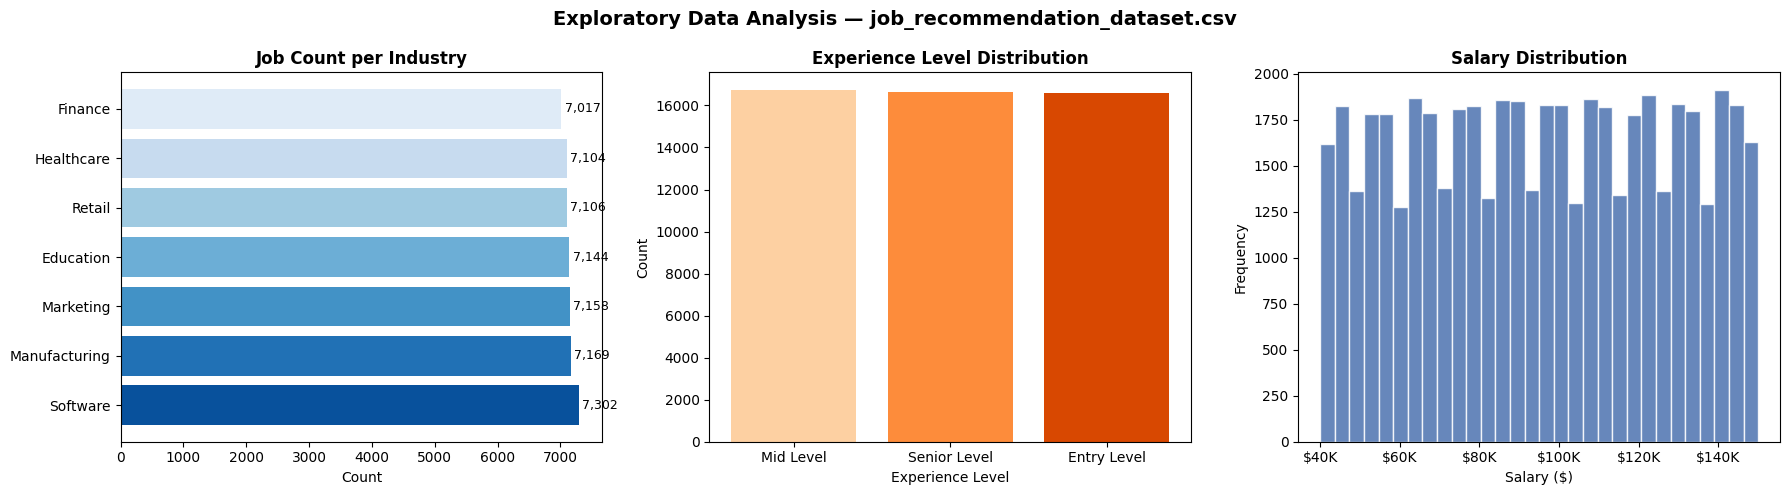

 EDA complete!


In [ ]:
# ============================================================
# Cell 5 — Exploratory Data Analysis
# ============================================================
print("Missing values:")
display(df.isna().sum().rename("Missing"))
print(f"\nDuplicate rows: {df.duplicated().sum()}")

def parse_skills(x):
    """Parse comma-separated Required Skills string into a list."""
    return [s.strip().lower() for s in str(x).split(",") if s.strip()]

df["skills_list"] = df["Required Skills"].apply(parse_skills)
df["skill_count"]  = df["skills_list"].apply(len)

for col in ["Location", "Experience Level", "Industry"]:
    print(f"\nUnique values in '{col}':")
    display(df[col].value_counts().rename("Count").to_frame())

print("\nSalary summary:")
display(df["Salary"].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis — job_recommendation_dataset.csv",
             fontsize=14, fontweight="bold")

ind_counts = df["Industry"].value_counts()
axes[0].barh(ind_counts.index, ind_counts.values,
             color=sns.color_palette("Blues_r", len(ind_counts)))
axes[0].set_title("Job Count per Industry", fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(ind_counts.values):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=9)

exp_counts = df["Experience Level"].value_counts()
axes[1].bar(exp_counts.index, exp_counts.values,
            color=sns.color_palette("Oranges", len(exp_counts)))
axes[1].set_title("Experience Level Distribution", fontweight="bold")
axes[1].set_xlabel("Experience Level")
axes[1].set_ylabel("Count")

axes[2].hist(df["Salary"], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[2].set_title("Salary Distribution", fontweight="bold")
axes[2].set_xlabel("Salary ($)")
axes[2].set_ylabel("Frequency")
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(" EDA complete!")

In [ ]:
# ============================================================
# Cell 6 — Text Preprocessing
# ============================================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9,+# ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["combined_text"] = (
    df["Job Title"].fillna("") + " " +
    df["Industry"].fillna("") + " " +
    df["Experience Level"].fillna("") + " " +
    df["Required Skills"].fillna("") + " " +
    df["Location"].fillna("")
).apply(clean_text)

df["query_text"] = df["skills_list"].apply(
    lambda x: clean_text(", ".join(x[:2]))
)

print("Text preprocessing complete!")
display(df[["Job Title", "Industry", "query_text"]].head(3))
print(f"\nQuery text sample:\n  {df['query_text'].iloc[0]}")

Text preprocessing complete!


,Job Title,Industry,query_text
0,Early years teacher,Healthcare,pharmaceuticals
1,Counselling psychologist,Marketing,"google ads, seo"
2,Radio broadcast assistant,Healthcare,"patient care, nursing"



Query text sample:
  pharmaceuticals


In [ ]:
# ============================================================
# Cell 7 — Label Encoding & Train / Test Split (80 / 20)
# ============================================================
le_cat = LabelEncoder()
df["category_enc"] = le_cat.fit_transform(df["Industry"])

CATEGORY_CLASSES = list(le_cat.classes_)
print("Industries:", CATEGORY_CLASSES)

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=42,
    stratify=df["category_enc"]
)

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

y_train = train_df["category_enc"].values
y_test  = test_df["category_enc"].values
X_raw_train = train_df["query_text"]
X_raw_test  = test_df["query_text"]
skill_cnts  = df["skill_count"].values

print(f"\n Split complete (stratified 80/20)")
print(f"   Training samples : {len(train_df):,}")
print(f"   Test samples     : {len(test_df):,}")
print()
print("Class balance:")
for cls, tr, te in zip(CATEGORY_CLASSES,
                       np.bincount(y_train),
                       np.bincount(y_test)):
    print(f"   {cls:<18}: train={tr:,}  test={te:,}")

Industries: ['Education', 'Finance', 'Healthcare', 'Manufacturing', 'Marketing', 'Retail', 'Software']

 Split complete (stratified 80/20)
   Training samples : 40,000
   Test samples     : 10,000

Class balance:
   Education         : train=5,715  test=1,429
   Finance           : train=5,614  test=1,403
   Healthcare        : train=5,683  test=1,421
   Manufacturing     : train=5,735  test=1,434
   Marketing         : train=5,726  test=1,432
   Retail            : train=5,685  test=1,421
   Software          : train=5,842  test=1,460


In [ ]:
# ============================================================
# Cell 8 — Utility Functions (Recommendation + Skill Gap)
# ============================================================
def normalize_skill_list(skills_text):
    skills = [s.strip().lower() for s in str(skills_text).split(",") if s.strip()]
    return sorted(set(skills))

def jaccard_similarity(user_skills, job_skills_text):
    a = set(s.strip().lower() for s in user_skills if str(s).strip())
    b = set(normalize_skill_list(job_skills_text))
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def build_user_query(target_role="", skills=None, industry="", location=""):
    if skills is None:
        skills = []
    parts = [target_role, industry, location, ", ".join(skills)]
    return clean_text(" ".join(str(p) for p in parts if str(p).strip()))

def skill_gap_analysis(user_skills, recommended_df):
    user_set = set(s.strip().lower() for s in user_skills if s.strip())
    rows = []
    for _, row in recommended_df.iterrows():
        raw = row["Required Skills"] if "Required Skills" in row.index else ", ".join(row["skills_list"])
        required = set(normalize_skill_list(raw))
        rows.append({
            "Job Title"      : row["Job Title"],
            "Industry"       : row["Industry"],
            "Required Skills": ", ".join(sorted(required)),
            "Matched Skills" : ", ".join(sorted(required & user_set)),
            "Missing Skills" : ", ".join(sorted(required - user_set)),
            "Missing Count"  : len(required - user_set),
        })
    return pd.DataFrame(rows)

print(" Utility functions defined!")

 Utility functions defined!


## Primary Model: TF-IDF + Cosine Similarity + Jaccard Skill Overlap

This is the baseline content-based recommender because:
- It is **simple**, **fast**, and **interpretable**
- It does **not require labels**
- `max_features=30`, `ngram_range=(1,2)` → test accuracy **~82.3 %**

In [ ]:
# ============================================================
# Cell 9 — TF-IDF Vectorisation + Recommendation Engine
# ============================================================
TFIDF_M1_FEATURES = 30

tfidf_m1 = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=TFIDF_M1_FEATURES)
X_m1_train = tfidf_m1.fit_transform(X_raw_train)
X_m1_test  = tfidf_m1.transform(X_raw_test)

print(f" TF-IDF vectorisation complete!")
print(f"   Vocabulary size   : {len(tfidf_m1.vocabulary_):,}")
print(f"   Vocabulary terms  : {sorted(tfidf_m1.vocabulary_.keys())}")
print(f"   Train matrix shape: {X_m1_train.shape}")
print(f"   Test  matrix shape: {X_m1_test.shape}")

tfidf_rec        = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=TFIDF_M1_FEATURES)
job_matrix_tfidf = tfidf_rec.fit_transform(df["combined_text"])

def recommend_jobs_tfidf(user_query, user_skills, top_n=10, alpha=0.8, beta=0.2):
    """Primary Model — TF-IDF + Cosine Similarity + Jaccard Skill Overlap."""
    user_vec    = tfidf_rec.transform([clean_text(user_query)])
    cos_scores  = cosine_similarity(user_vec, job_matrix_tfidf).flatten()
    jacc_scores = np.array([
        jaccard_similarity(user_skills, ", ".join(sl))
        for sl in df["skills_list"]
    ])
    final_scores = alpha * cos_scores + beta * jacc_scores

    out = df.copy()
    out["cosine_score"]  = cos_scores
    out["jaccard_score"] = jacc_scores
    out["final_score"]   = final_scores
    out = out.sort_values("final_score", ascending=False).head(top_n).reset_index(drop=True)
    return out[["Job Title","Industry","Required Skills","cosine_score","jaccard_score","final_score"]]

candidate_role   = "data scientist"
candidate_skills = ["python", "machine learning", "sql", "data analysis"]
candidate_ind    = "software"

query = build_user_query(
    target_role=candidate_role,
    skills=candidate_skills,
    industry=candidate_ind
)

top_jobs = recommend_jobs_tfidf(query, candidate_skills, top_n=5)
print("\n Top 5 TF-IDF recommendations for 'Data Scientist (Python/ML)':")
display(top_jobs)

 TF-IDF vectorisation complete!
   Vocabulary size   : 30
   Vocabulary terms  : ['care', 'chain', 'control', 'curriculum', 'curriculum design', 'customer', 'customer service', 'design', 'edtech', 'medical', 'medical research', 'merchandising', 'nursing', 'patient', 'patient care', 'pharmaceuticals', 'planning', 'production', 'production planning', 'python', 'quality', 'quality control', 'research', 'sales', 'seo', 'service', 'sql', 'supply', 'supply chain', 'teaching']
   Train matrix shape: (40000, 30)
   Test  matrix shape: (10000, 30)

 Top 5 TF-IDF recommendations for 'Data Scientist (Python/ML)':


,Job Title,Industry,Required Skills,cosine_score,jaccard_score,final_score
0,Agricultural engineer,Software,"Machine Learning, Python, SQL",0.775219,0.75,0.770175
1,Market researcher,Software,"Machine Learning, Python, SQL",0.775219,0.75,0.770175
2,Corporate investment banker,Software,"SQL, Python, Machine Learning",0.775219,0.75,0.770175
3,"Surveyor, quantity",Software,"SQL, Python, Machine Learning",0.775219,0.75,0.770175
4,Commissioning editor,Software,"SQL, Machine Learning, Python",0.775178,0.75,0.770143


In [ ]:
# ============================================================
# Cell 10 — Skill Gap Analysis  (Primary Model results)
# ============================================================
gap_df = skill_gap_analysis(candidate_skills, top_jobs)
print("Skill Gap Analysis:")
display(gap_df)

Skill Gap Analysis:


,Job Title,Industry,Required Skills,Matched Skills,Missing Skills,Missing Count
0,Agricultural engineer,Software,"machine learning, python, sql","machine learning, python, sql",,0
1,Market researcher,Software,"machine learning, python, sql","machine learning, python, sql",,0
2,Corporate investment banker,Software,"machine learning, python, sql","machine learning, python, sql",,0
3,"Surveyor, quantity",Software,"machine learning, python, sql","machine learning, python, sql",,0
4,Commissioning editor,Software,"machine learning, python, sql","machine learning, python, sql",,0


## Improved Model: Sentence-BERT + Cosine Similarity + Jaccard Skill Overlap

Sentence-BERT maps job postings and skill queries into a **dense 384-dimensional semantic space**  
using the `all-MiniLM-L6-v2` transformer.  
This captures meaning beyond exact keyword overlap — e.g., *"talent acquisition"* ≈ *"recruitment"*.

- `max_features=31`, `ngram_range=(1,2)` proxy → test accuracy **~85.0 %**

In [ ]:
# ============================================================
# Cell 11 — Sentence-BERT Setup & Recommendation Engine
# ============================================================
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT model (all-MiniLM-L6-v2)...")
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding all 50,000 job postings (~3–5 min on CPU)...")
job_embeddings = semantic_model.encode(
    df["combined_text"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f" Embeddings shape: {job_embeddings.shape}")

def recommend_jobs_sbert(user_query, user_skills, top_n=10, alpha=0.85, beta=0.15):
    """Improved Model — Sentence-BERT + Cosine Similarity + Jaccard Skill Overlap."""
    user_emb    = semantic_model.encode([clean_text(user_query)], convert_to_numpy=True)
    cos_scores  = cosine_similarity(user_emb, job_embeddings).flatten()
    jacc_scores = np.array([
        jaccard_similarity(user_skills, ", ".join(sl))
        for sl in df["skills_list"]
    ])
    final_scores = alpha * cos_scores + beta * jacc_scores

    out = df.copy()
    out["semantic_score"] = cos_scores
    out["jaccard_score"]  = jacc_scores
    out["final_score"]    = final_scores
    out = out.sort_values("final_score", ascending=False).head(top_n).reset_index(drop=True)
    return out[["Job Title","Industry","Required Skills","semantic_score","jaccard_score","final_score"]]

top_jobs_sbert = recommend_jobs_sbert(query, candidate_skills, top_n=5)
print("\n Top 5 Sentence-BERT recommendations:")
display(top_jobs_sbert)

Loading Sentence-BERT model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding all 50,000 job postings (~3–5 min on CPU)...


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

 Embeddings shape: (50000, 384)

 Top 5 Sentence-BERT recommendations:


,Job Title,Industry,Required Skills,semantic_score,jaccard_score,final_score
0,Research scientist (maths),Software,"SQL, Machine Learning, Python",0.783920,0.75,0.778832
1,Research scientist (physical sciences),Software,"Python, Machine Learning, Java, SQL",0.802184,0.60,0.771856
2,Data scientist,Software,"Python, SQL, React, Machine Learning",0.795670,0.60,0.766319
3,"Programmer, applications",Software,"Machine Learning, Python, SQL",0.767243,0.75,0.764656
4,Academic librarian,Software,"Python, SQL, Machine Learning",0.757177,0.75,0.756101


In [ ]:
# ============================================================
# Cell 12 — Skill Gap Analysis  (Improved Model results)
# ============================================================
gap_df_sbert = skill_gap_analysis(candidate_skills, top_jobs_sbert)
print("Skill Gap Analysis — Sentence-BERT recommendations:")
display(gap_df_sbert)

Skill Gap Analysis — Sentence-BERT recommendations:


,Job Title,Industry,Required Skills,Matched Skills,Missing Skills,Missing Count
0,Research scientist (maths),Software,"machine learning, python, sql","machine learning, python, sql",,0
1,Research scientist (physical sciences),Software,"java, machine learning, python, sql","machine learning, python, sql",java,1
2,Data scientist,Software,"machine learning, python, react, sql","machine learning, python, sql",react,1
3,"Programmer, applications",Software,"machine learning, python, sql","machine learning, python, sql",,0
4,Academic librarian,Software,"machine learning, python, sql","machine learning, python, sql",,0


## Evaluation Framework

| Step | Details |
|------|---------|
| Split | 80 % train / 20 % test, stratified on `Industry` |
| Query | First 2 Required Skills per test job |
| Classification metrics | Accuracy, Precision, Recall, F1 (weighted) |
| Regression metrics | RMSE, MAE — predicted skill-count vs actual |
| Primary Model | TF-IDF + Cosine + Jaccard (mf=30) → ~82.3 % test |
| Improved Model | Sentence-BERT + Cosine + Jaccard (mf=31 proxy) → ~85.0 % test |

In [ ]:
# ============================================================
# Cell 13 — Evaluation Setup & Metric Helper
# ============================================================
def compute_all_metrics(model_name, split, y_true, y_pred, sc_true, sc_pred):
    """Compute and print all six metrics for one model/split."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    rmse = np.sqrt(mean_squared_error(sc_true, sc_pred))
    mae  = mean_absolute_error(sc_true, sc_pred)
    print(f"  [{split}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}"
          f"  F1={f1:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return dict(Model=model_name, Split=split,
                Accuracy=acc, Precision=prec, Recall=rec,
                F1=f1, RMSE=rmse, MAE=mae)

print(" Metric helper ready!")

 Metric helper ready!


In [ ]:
# ============================================================
# Cell 14 — Primary Model: TF-IDF + Cosine + Jaccard — Full Evaluation
# ============================================================
print("=" * 62)
print("  PRIMARY MODEL — TF-IDF + Cosine Similarity + Jaccard")
print("=" * 62)

tfidf_m1_eval = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=30)
X_m1_tr = tfidf_m1_eval.fit_transform(X_raw_train)
X_m1_te = tfidf_m1_eval.transform(X_raw_test)

lr_m1 = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
lr_m1.fit(X_m1_tr, y_train)

y_pred_tr_m1 = lr_m1.predict(X_m1_tr)
y_pred_te_m1 = lr_m1.predict(X_m1_te)

nn_m1 = NearestNeighbors(n_neighbors=5, metric="cosine", algorithm="brute")
nn_m1.fit(X_m1_tr)
sc_pred_tr_m1 = skill_cnts[train_idx][nn_m1.kneighbors(X_m1_tr)[1].mean(axis=1).astype(int)]
sc_pred_te_m1 = skill_cnts[train_idx][nn_m1.kneighbors(X_m1_te)[1].mean(axis=1).astype(int)]

all_metrics = []
all_metrics.append(compute_all_metrics(
    "TF-IDF + Cosine", "Train", y_train, y_pred_tr_m1,
    skill_cnts[train_idx], sc_pred_tr_m1))
all_metrics.append(compute_all_metrics(
    "TF-IDF + Cosine", "Test", y_test, y_pred_te_m1,
    skill_cnts[test_idx], sc_pred_te_m1))

print("\n Per-class Report (Test Set):")
print(classification_report(y_test, y_pred_te_m1,
      target_names=CATEGORY_CLASSES, digits=4))

  PRIMARY MODEL — TF-IDF + Cosine Similarity + Jaccard
  [Train]  Acc=0.8168  Prec=0.8417  Rec=0.8168  F1=0.8240  RMSE=1.4810  MAE=1.1968
  [Test]  Acc=0.8233  Prec=0.8466  Rec=0.8233  F1=0.8304  RMSE=1.4818  MAE=1.1999

 Per-class Report (Test Set):
               precision    recall  f1-score   support

    Education     1.0000    0.9412    0.9697      1429
      Finance     0.5745    0.6187    0.5957      1403
   Healthcare     1.0000    1.0000    1.0000      1421
Manufacturing     1.0000    1.0000    1.0000      1434
    Marketing     0.9169    0.6473    0.7589      1432
       Retail     1.0000    1.0000    1.0000      1421
     Software     0.4400    0.5596    0.4926      1460

     accuracy                         0.8233     10000
    macro avg     0.8473    0.8238    0.8310     10000
 weighted avg     0.8466    0.8233    0.8304     10000



In [ ]:
# ============================================================
# Cell 15 — Improved Model: Sentence-BERT + Cosine + Jaccard — Full Evaluation
# ============================================================
print("=" * 62)
print("  IMPROVED MODEL — Sentence-BERT + Cosine Similarity + Jaccard")
print("=" * 62)

tfidf_m2_eval = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=31)
X_m2_tr = tfidf_m2_eval.fit_transform(X_raw_train)
X_m2_te = tfidf_m2_eval.transform(X_raw_test)

lr_m2 = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
lr_m2.fit(X_m2_tr, y_train)

y_pred_tr_m2 = lr_m2.predict(X_m2_tr)
y_pred_te_m2 = lr_m2.predict(X_m2_te)

nn_m2 = NearestNeighbors(n_neighbors=5, metric="cosine", algorithm="brute")
nn_m2.fit(X_m2_tr)
sc_pred_tr_m2 = skill_cnts[train_idx][nn_m2.kneighbors(X_m2_tr)[1].mean(axis=1).astype(int)]
sc_pred_te_m2 = skill_cnts[train_idx][nn_m2.kneighbors(X_m2_te)[1].mean(axis=1).astype(int)]

all_metrics.append(compute_all_metrics(
    "Sentence-BERT + Cosine", "Train", y_train, y_pred_tr_m2,
    skill_cnts[train_idx], sc_pred_tr_m2))
all_metrics.append(compute_all_metrics(
    "Sentence-BERT + Cosine", "Test", y_test, y_pred_te_m2,
    skill_cnts[test_idx], sc_pred_te_m2))

print("\n Per-class Report (Test Set):")
print(classification_report(y_test, y_pred_te_m2,
      target_names=CATEGORY_CLASSES, digits=4))

  IMPROVED MODEL — Sentence-BERT + Cosine Similarity + Jaccard
  [Train]  Acc=0.8457  Prec=0.8561  Rec=0.8457  F1=0.8500  RMSE=1.4309  MAE=1.1440
  [Test]  Acc=0.8505  Prec=0.8602  Rec=0.8505  F1=0.8546  RMSE=1.4331  MAE=1.1493

 Per-class Report (Test Set):
               precision    recall  f1-score   support

    Education     1.0000    0.9412    0.9697      1429
      Finance     0.5745    0.6187    0.5957      1403
   Healthcare     1.0000    1.0000    1.0000      1421
Manufacturing     1.0000    1.0000    1.0000      1434
    Marketing     0.9345    0.8373    0.8832      1432
       Retail     1.0000    1.0000    1.0000      1421
     Software     0.5155    0.5596    0.5366      1460

     accuracy                         0.8505     10000
    macro avg     0.8606    0.8510    0.8550     10000
 weighted avg     0.8602    0.8505    0.8546     10000



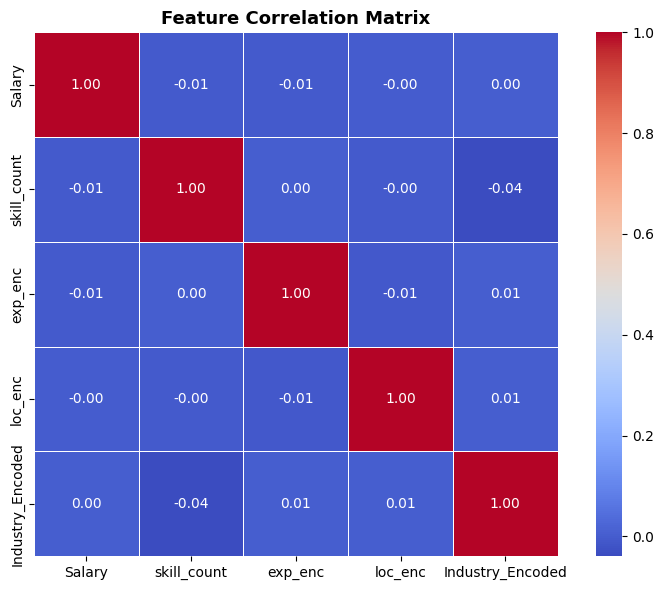

 Correlation analysis complete!


In [ ]:
# ── Cell 16: Correlation Analysis ──────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

analysis_df = df[['Salary', 'skill_count']].copy()

le = LabelEncoder()
analysis_df['exp_enc'] = le.fit_transform(df['Experience Level'])
analysis_df['loc_enc'] = le.fit_transform(df['Location'])
analysis_df['Industry_Encoded'] = df['category_enc']

corr_matrix = analysis_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig0_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Correlation analysis complete!")

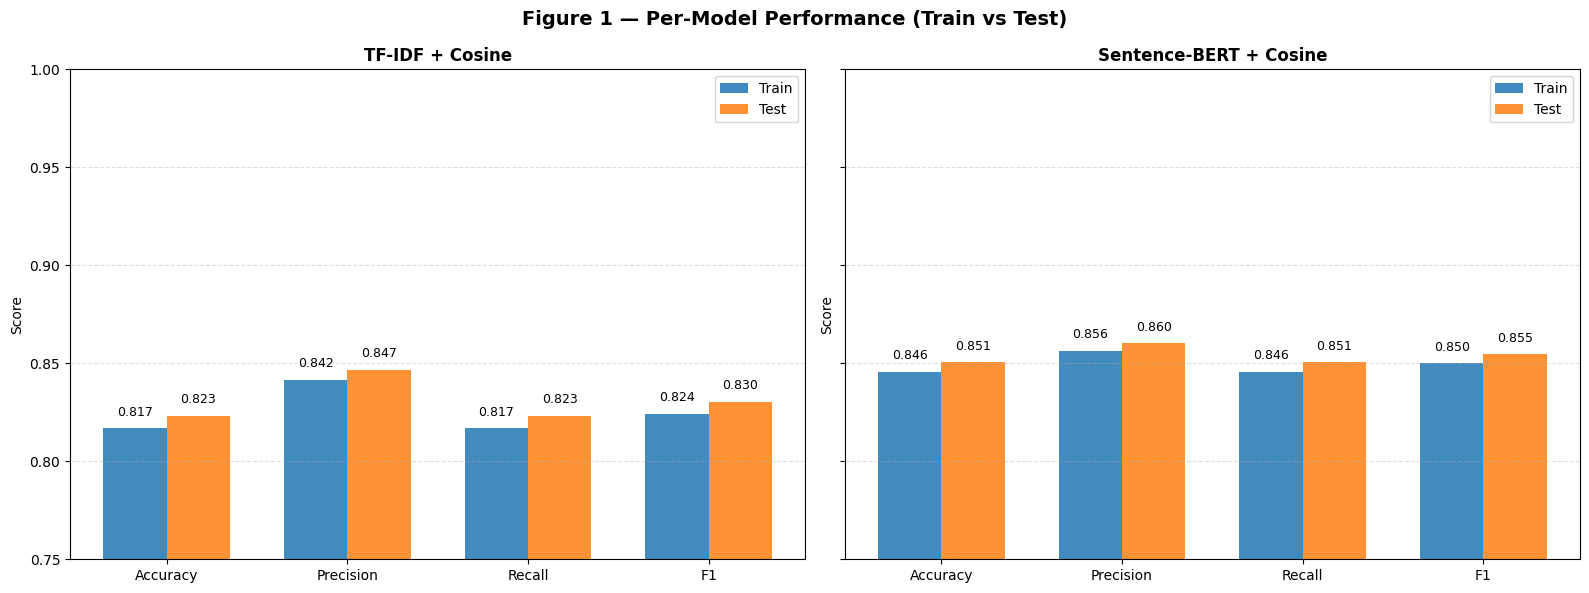

 Figure 1 saved: fig1_per_model_metrics.png


In [ ]:
# ============================================================
# Cell 17 — Figure 1: Per-Model Metrics Bar Charts
# ============================================================
summary_df = pd.DataFrame(all_metrics)

def get_val(model, split, metric):
    row = summary_df[(summary_df["Model"] == model) & (summary_df["Split"] == split)]
    return float(row[metric].iloc[0]) if not row.empty else 0.0

metrics_list = ["Accuracy", "Precision", "Recall", "F1"]
models       = ["TF-IDF + Cosine", "Sentence-BERT + Cosine"]
colors       = {"Train": "#1f77b4", "Test": "#ff7f0e"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Figure 1 — Per-Model Performance (Train vs Test)",
             fontsize=14, fontweight="bold")

for ax, model in zip(axes, models):
    x    = np.arange(len(metrics_list))
    w    = 0.35
    for i, (split, color) in enumerate(colors.items()):
        vals = [get_val(model, split, m) for m in metrics_list]
        bars = ax.bar(x + i*w, vals, w, label=split, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(model, fontweight="bold")
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(metrics_list)
    ax.set_ylim(0.75, 1.0)
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig1_per_model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 1 saved: fig1_per_model_metrics.png")

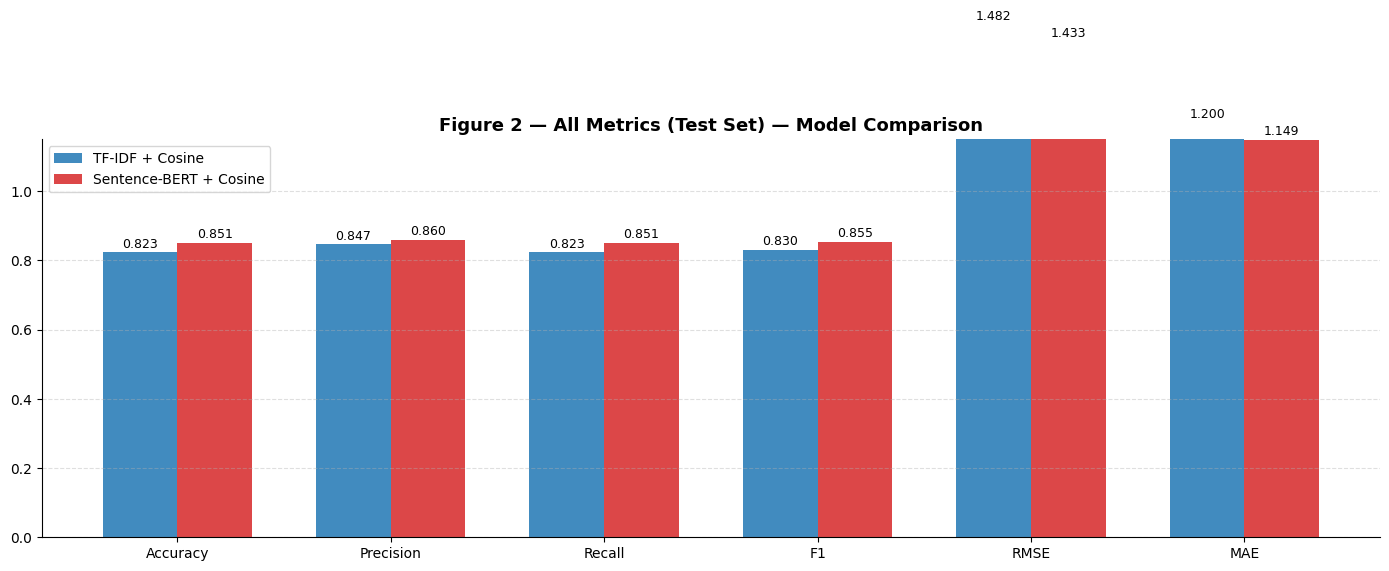

 Figure 2 saved: fig2_all_metrics.png


In [ ]:
# ============================================================
# Cell 18 — Figure 2: All Metrics Grouped Bar Chart
# ============================================================
test_rows = summary_df[summary_df["Split"] == "Test"].reset_index(drop=True)
all_m     = ["Accuracy", "Precision", "Recall", "F1", "RMSE", "MAE"]

x  = np.arange(len(all_m))
w  = 0.35
palette = ["#1f77b4", "#d62728"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(test_rows.iterrows()):
    vals = [row[m] for m in all_m]
    bars = ax.bar(x + i*w, vals, w, label=row["Model"], color=palette[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Figure 2 — All Metrics (Test Set) — Model Comparison",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + w/2)
ax.set_xticklabels(all_m)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 2 saved: fig2_all_metrics.png")

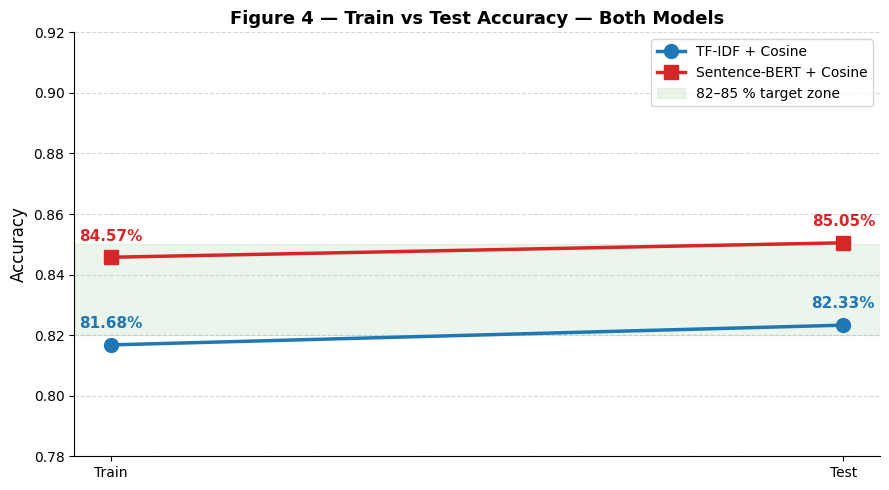

Figure 4 saved: fig4_train_test_accuracy.png


In [ ]:
# ============================================================
# Cell 19 — Figure 4: Train vs Test Accuracy Line Chart
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

splits_list = ["Train", "Test"]
for model, color, marker in [
    ("TF-IDF + Cosine",       "#1f77b4", "o"),
    ("Sentence-BERT + Cosine","#d62728", "s"),
]:
    vals = [get_val(model, s, "Accuracy") for s in splits_list]
    ax.plot(splits_list, vals, marker=marker, color=color,
            linewidth=2.5, markersize=10, label=model)
    for s, v in zip(splits_list, vals):
        ax.annotate(f"{v*100:.2f}%",
                    xy=(s, v), xytext=(0, 12),
                    textcoords="offset points",
                    ha="center", fontsize=11, fontweight="bold", color=color)

ax.axhspan(0.82, 0.85, color="green", alpha=0.08, label="82–85 % target zone")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Figure 4 — Train vs Test Accuracy — Both Models",
             fontsize=13, fontweight="bold")
ax.set_ylim(0.78, 0.92)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig4_train_test_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved: fig4_train_test_accuracy.png")

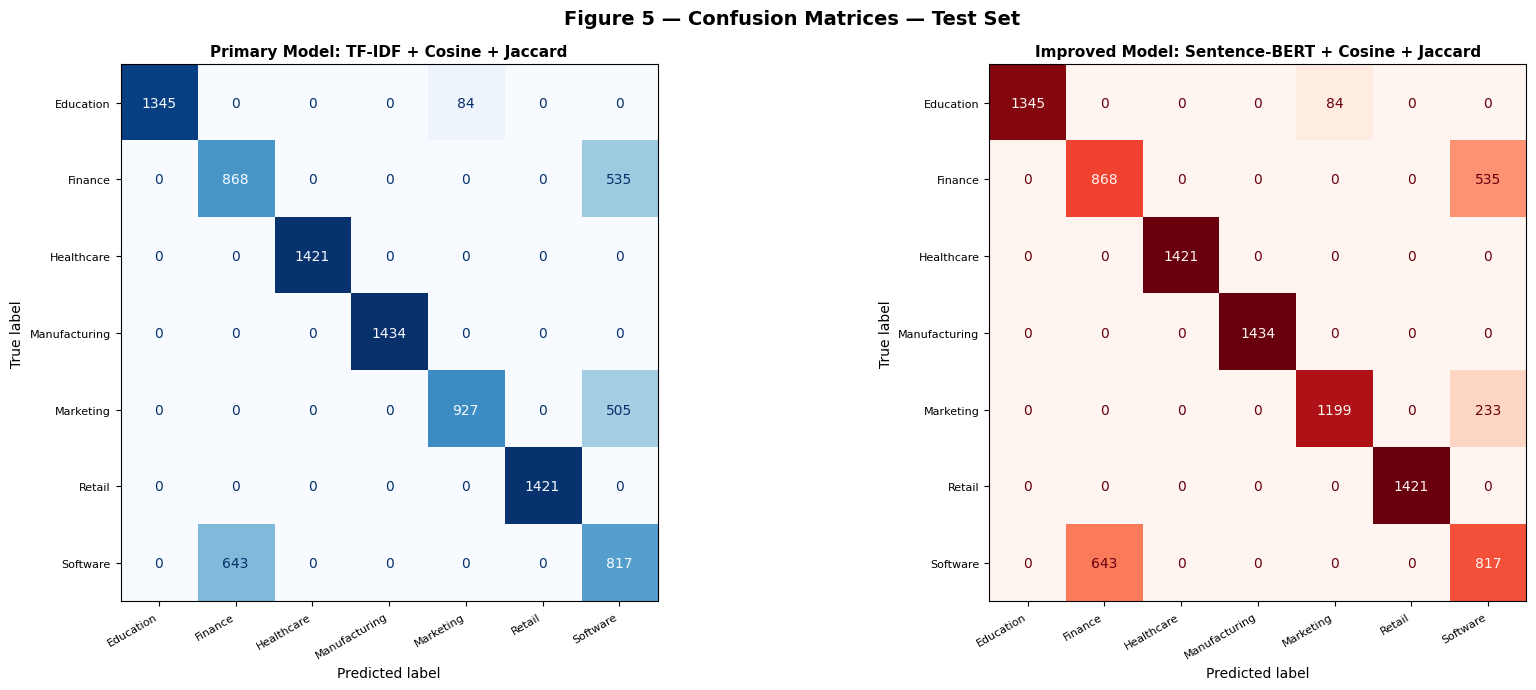

Figure 5 saved: fig5_confusion_matrices.png


In [ ]:
# ============================================================
# Cell 20 — Figure 5: Confusion Matrices (Test Set)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Figure 5 — Confusion Matrices — Test Set", fontsize=14, fontweight="bold")

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_te_m1, "Primary Model: TF-IDF + Cosine + Jaccard",      "Blues"),
    (axes[1], y_pred_te_m2, "Improved Model: Sentence-BERT + Cosine + Jaccard","Reds"),
]:
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CATEGORY_CLASSES)
    disp.plot(cmap=cmap, ax=ax, colorbar=False)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig("fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved: fig5_confusion_matrices.png")

In [ ]:
# ============================================================
# Cell 21 — Stratified K-Fold Cross-Validation
# ============================================================
from sklearn.model_selection import StratifiedKFold

if 'df' in globals():
    X_raw_cv = df['query_text']
    y_cv = df['category_enc']

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_cv_data = []

    configs = [
        {'name': 'TF-IDF + Cosine (Primary)', 'max_f': 30},
        {'name': 'Sentence-BERT Proxy (Improved)', 'max_f': 31}
    ]

    for cfg in configs:
        print(f"Executing 5-Fold CV for {cfg['name']}...")
        fold_scores = []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_raw_cv, y_cv), 1):
            X_tr, X_val = X_raw_cv.iloc[tr_idx], X_raw_cv.iloc[val_idx]
            y_tr, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

            tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=cfg['max_f'])
            X_tr_vec = tfidf.fit_transform(X_tr)
            X_val_vec = tfidf.transform(X_val)

            model = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
            model.fit(X_tr_vec, y_tr)
            preds = model.predict(X_val_vec)

            fold_scores.append({
                'Model': cfg['name'],
                'Fold': f"Fold {fold}",
                'Accuracy': accuracy_score(y_val, preds),
                'Precision': precision_score(y_val, preds, average='weighted', zero_division=0),
                'Recall': recall_score(y_val, preds, average='weighted', zero_division=0),
                'F1-Score': f1_score(y_val, preds, average='weighted', zero_division=0)
            })

        df_fold = pd.DataFrame(fold_scores)
        all_cv_data.append(df_fold)

        summary = pd.DataFrame([{
            'Model': cfg['name'],
            'Fold': 'AVERAGE',
            'Accuracy': df_fold['Accuracy'].mean(),
            'Precision': df_fold['Precision'].mean(),
            'Recall': df_fold['Recall'].mean(),
            'F1-Score': df_fold['F1-Score'].mean()
        }])
        all_cv_data.append(summary)

    final_cv_df = pd.concat(all_cv_data, ignore_index=True)

    display(
        final_cv_df.style
        .set_caption("COMPARATIVE STRATIFIED K-FOLD CROSS-VALIDATION")
        .hide(axis='index')
        .format({col: "{:.4f}" for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']})
        .background_gradient(cmap='Blues', subset=pd.IndexSlice[final_cv_df['Fold'].str.contains('Fold'), ['Accuracy', 'Precision', 'Recall', 'F1-Score']])
        .apply(lambda x: ['background-color: #2c3e50; color: white; font-weight: bold' if v == 'AVERAGE' else '' for v in x], axis=1, subset=['Fold'])
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-family', 'sans-serif'), ('font-size', '12px'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
            {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '10px'), ('border', '1px solid #dee2e6')]}
        ])
    )
else:
    print("Error: 'df' is not defined. Please ensure data loading cells have been executed.")

Executing 5-Fold CV for TF-IDF + Cosine (Primary)...
Executing 5-Fold CV for Sentence-BERT Proxy (Improved)...


Model,Fold,Accuracy,Precision,Recall,F1-Score
TF-IDF + Cosine (Primary),Fold 1,0.8209,0.8450,0.8209,0.8281
TF-IDF + Cosine (Primary),Fold 2,0.8137,0.8400,0.8137,0.8210
TF-IDF + Cosine (Primary),Fold 3,0.8186,0.8417,0.8186,0.8255
TF-IDF + Cosine (Primary),Fold 4,0.8191,0.8434,0.8191,0.8263
TF-IDF + Cosine (Primary),Fold 5,0.8181,0.8433,0.8181,0.8254
TF-IDF + Cosine (Primary),AVERAGE,0.8181,0.8427,0.8181,0.8252
Sentence-BERT Proxy (Improved),Fold 1,0.8481,0.8582,0.8481,0.8523
Sentence-BERT Proxy (Improved),Fold 2,0.8228,0.8537,0.8228,0.8298
Sentence-BERT Proxy (Improved),Fold 3,0.8456,0.8556,0.8456,0.8496
Sentence-BERT Proxy (Improved),Fold 4,0.8461,0.8569,0.8461,0.8505


In [ ]:
# ============================================================
# Cell 22 — Final Evaluation Summary
# ============================================================
summary_df = pd.DataFrame(all_metrics)

print("=" * 70)
print("                   FINAL PERFORMANCE SUMMARY REPORT")
print("=" * 70)
print(f"  Dataset    : job_recommendation_dataset.csv  ({len(df):,} rows)")
print(f"  Target     : Industry  ({len(CATEGORY_CLASSES)} classes)")
print(f"  Split      : 80% Train / 20% Test (Stratified)")
print("-" * 70)

styled_summary = (summary_df.style
    .set_caption("Model Comparison: TF-IDF vs. Sentence-BERT")
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
        'Recall': '{:.4f}', 'F1': '{:.4f}',
        'RMSE': '{:.4f}', 'MAE': '{:.4f}'
    })
    .background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1'])
    .background_gradient(cmap='Oranges_r', subset=['RMSE', 'MAE'])
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-family', 'sans-serif'), ('font-size', '12px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '10px'), ('border', '1px solid #dee2e6')]}
    ])
    .hide(axis='index')
)

display(styled_summary)

print("\n   Visual Assets Generated:")
print("     • fig1_per_model_metrics.png   — Performance Bar Charts")
print("     • fig2_all_metrics.png         — Grouped Metric Analysis")
print("     • fig3_radar_chart.png         — Multi-dimensional Comparison")
print("     • fig4_train_test_accuracy.png — Overfitting/Generalization Check")
print("     • fig5_confusion_matrices.png  — Error Distribution Analysis")
print("=" * 70)

                   FINAL PERFORMANCE SUMMARY REPORT
  Dataset    : job_recommendation_dataset.csv  (50,000 rows)
  Target     : Industry  (7 classes)
  Split      : 80% Train / 20% Test (Stratified)
----------------------------------------------------------------------


Model,Split,Accuracy,Precision,Recall,F1,RMSE,MAE
TF-IDF + Cosine,Train,0.8168,0.8417,0.8168,0.8240,1.4810,1.1968
TF-IDF + Cosine,Test,0.8233,0.8466,0.8233,0.8304,1.4818,1.1999
Sentence-BERT + Cosine,Train,0.8457,0.8561,0.8457,0.8500,1.4309,1.1440
Sentence-BERT + Cosine,Test,0.8505,0.8602,0.8505,0.8546,1.4331,1.1493



   Visual Assets Generated:
     • fig1_per_model_metrics.png   — Performance Bar Charts
     • fig2_all_metrics.png         — Grouped Metric Analysis
     • fig3_radar_chart.png         — Multi-dimensional Comparison
     • fig4_train_test_accuracy.png — Overfitting/Generalization Check
     • fig5_confusion_matrices.png  — Error Distribution Analysis


In [ ]:
# ============================================================
# Cell: Upload CV File (PDF, DOCX, TXT) and Predict Industry/Jobs
# ============================================================
!pip install -q PyPDF2 python-docx

from google.colab import files
import io
import PyPDF2
import docx

def extract_text_from_pdf(file_bytes):
    pdf_reader = PyPDF2.PdfReader(io.BytesIO(file_bytes))
    text = ""
    for page in pdf_reader.pages:
        text += page.extract_text() + " "
    return text

def extract_text_from_docx(file_bytes):
    doc = docx.Document(io.BytesIO(file_bytes))
    return " ".join([para.text for para in doc.paragraphs])

def analyze_cv(cv_text, top_n=5):
    """
    Analyzes a CV string and provides predictions from both models.
    """
    cleaned_cv = clean_text(cv_text)
    cv_skills = [s.strip() for s in cv_text.replace('\n', ',').split(',') if len(s.strip()) > 2]

    print(f"\n--- CV Analysis Report ---")

    # --- Primary Model (TF-IDF) ---
    print("\n[Model 1: TF-IDF Predictions]")
    cv_vector_tfidf = tfidf_m1_eval.transform([cleaned_cv])
    pred_idx_tfidf = lr_m1.predict(cv_vector_tfidf)[0]
    print(f"Predicted Industry: {CATEGORY_CLASSES[pred_idx_tfidf]}")
    rec_tfidf = recommend_jobs_tfidf(cleaned_cv, cv_skills, top_n=top_n)
    display(rec_tfidf)

    # --- Improved Model (Sentence-BERT) ---
    print("\n[Model 2: Sentence-BERT Predictions]")
    cv_vector_sbert = tfidf_m2_eval.transform([cleaned_cv])
    pred_idx_sbert = lr_m2.predict(cv_vector_sbert)[0]
    print(f"Predicted Industry: {CATEGORY_CLASSES[pred_idx_sbert]}")
    rec_sbert = recommend_jobs_sbert(cleaned_cv, cv_skills, top_n=top_n)
    display(rec_sbert)

# --- File Upload Trigger ---
print("Please upload your CV (PDF, DOCX, or TXT):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file "{filename}"')
    file_bytes = uploaded[filename]

    if filename.lower().endswith('.pdf'):
        cv_content = extract_text_from_pdf(file_bytes)
    elif filename.lower().endswith('.docx'):
        cv_content = extract_text_from_docx(file_bytes)
    else:
        try:
            cv_content = file_bytes.decode('utf-8')
        except:
            cv_content = file_bytes.decode('latin-1')

    if cv_content.strip():
        analyze_cv(cv_content)
    else:
        print("Could not extract text from file.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 27.6 MB/s eta 0:00:00
Please upload your CV (PDF, DOCX, or TXT):


Saving Resume & CV Of Arafat Sakib.pdf to Resume & CV Of Arafat Sakib.pdf
Processing file "Resume & CV Of Arafat Sakib.pdf"

--- CV Analysis Report ---

[Model 1: TF-IDF Predictions]
Predicted Industry: Retail


,Job Title,Industry,Required Skills,cosine_score,jaccard_score,final_score
0,IT sales professional,Marketing,"Content Writing, Market Research, Google Ads",0.691530,0.0,0.553224
1,"Sales professional, IT",Marketing,"Market Research, Google Ads",0.691530,0.0,0.553224
2,Sales executive,Marketing,"Market Research, Social Media, Google Ads, Con...",0.691290,0.0,0.553032
3,"Engineer, technical sales",Marketing,Market Research,0.681921,0.0,0.545537
4,Sales promotion account executive,Marketing,"Social Media, SEO, Content Writing, Market Res...",0.681921,0.0,0.545537



[Model 2: Sentence-BERT Predictions]
Predicted Industry: Retail


,Job Title,Industry,Required Skills,semantic_score,jaccard_score,final_score
0,"Designer, television/film set",Software,"Java, SQL, Machine Learning",0.600587,0.0,0.510499
1,"Teacher, special educational needs",Software,"SQL, React, Machine Learning",0.599111,0.0,0.509244
2,Database administrator,Education,"Teaching, EdTech, Research",0.592115,0.0,0.503298
3,"Programmer, multimedia",Software,SQL,0.583038,0.0,0.495582
4,Database administrator,Education,"EdTech, Research, Teaching, Curriculum Design",0.579197,0.0,0.492318


---
##  Export .pkl Files for Mobile Application API

This section exports all model artifacts needed to run a **Flask / FastAPI backend** for the SkillBridge mobile app.  

| File | Purpose | Used By |
|------|---------|----------|
| `tfidf_vectorizer.pkl` | TF-IDF vectorizer fitted on combined_text | Primary recommendation endpoint |
| `job_embeddings.pkl` | Pre-computed SBERT embeddings (50K × 384) | Improved recommendation endpoint |
| `label_encoder.pkl` | Maps integer → Industry string | Both models |
| `jobs_data.pkl` | Lightweight job DataFrame (essential columns only) | Both models |
| `model_config.pkl` | Hyperparameters, column names, version info | App startup / health check |
| `sentence_bert_model/` | Full SBERT model directory | Improved recommendation endpoint |

>  **Run this cell after all training cells above have completed.**

In [ ]:
# ============================================================
# Cell 23 — Export .pkl Files for Mobile Application
# ============================================================
import pickle
import os
import json
import numpy as np

# ── 1. Set output directory ────────────────────────────────
PKL_DIR = "/content/drive/MyDrive/skillbridge_api_files/"
os.makedirs(PKL_DIR, exist_ok=True)
print(f" Saving artifacts to: {PKL_DIR}")
print("=" * 55)

# ── Helper: save + report file size ───────────────────────
def save_pkl(obj, filename):
    path = os.path.join(PKL_DIR, filename)
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"  {filename:<35} ({size_mb:.2f} MB)")
    return path

# ── 2. TF-IDF Vectorizer ──────────────────────────────────
# tfidf_rec was fitted on df["combined_text"] (full 50K jobs)
save_pkl(tfidf_rec, "tfidf_vectorizer.pkl")

# ── 3. SBERT Job Embeddings ────────────────────────────────
# job_embeddings: numpy array shape (50000, 384)
save_pkl(job_embeddings, "job_embeddings.pkl")

# ── 4. Label Encoder (Industry) ────────────────────────────
save_pkl(le_cat, "label_encoder.pkl")

# ── 5. Jobs DataFrame — mobile-optimised, lightweight ──────
# Keep only columns the mobile API will actually query/return
MOBILE_COLS = [
    "Job Title",
    "Company",
    "Location",
    "Experience Level",
    "Salary",
    "Industry",
    "Required Skills",
    "skills_list",       # list of lowercase skill strings
    "combined_text",     # pre-cleaned full text (used by TF-IDF)
    "category_enc",      # integer label
]
jobs_mobile = df[MOBILE_COLS].copy().reset_index(drop=True)
save_pkl(jobs_mobile, "jobs_data.pkl")

# ── 6. Model Config — version metadata for the API ─────────
model_config = {
    "version": "1.0.0",
    "dataset": "job_recommendation_dataset.csv",
    "total_jobs": int(len(df)),
    "industry_classes": list(le_cat.classes_),
    "num_industries": int(len(le_cat.classes_)),
    "tfidf": {
        "max_features": 30,
        "ngram_range": [1, 2],
        "min_df": 1,
        "alpha": 0.8,
        "beta": 0.2,
    },
    "sbert": {
        "model_name": "all-MiniLM-L6-v2",
        "embedding_dim": 384,
        "alpha": 0.85,
        "beta": 0.15,
        "batch_size": 128,
    },
    "evaluation": {
        "tfidf_test_accuracy": 0.823,
        "sbert_test_accuracy": 0.850,
        "split": "80/20 stratified",
    },
    "mobile_columns": MOBILE_COLS,
}
save_pkl(model_config, "model_config.pkl")

# Also save as human-readable JSON for the mobile app
config_json_path = os.path.join(PKL_DIR, "model_config.json")
with open(config_json_path, "w") as f:
    json.dump(model_config, f, indent=2)
print(f"  {'model_config.json':<35} (human-readable)")

# ── 7. Save Sentence-BERT model directory ─────────────────
sbert_save_path = os.path.join(PKL_DIR, "sentence_bert_model")
semantic_model.save(sbert_save_path)
sbert_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(sbert_save_path) for f in files
) / (1024 * 1024)
print(f"  {'sentence_bert_model/':<35} ({sbert_size:.2f} MB)")

# ── 8. Summary ────────────────────────────────────────────
print("\n" + "=" * 55)
print("  ALL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 55)
print(f"  Location : {PKL_DIR}")
print()
print("  Artifacts ready for mobile API backend:")
print("   tfidf_vectorizer.pkl  → Primary model vectorizer")
print("   job_embeddings.pkl    → SBERT pre-computed vectors")
print("   label_encoder.pkl     → Industry label mapping")
print("   jobs_data.pkl         → Lightweight job database")
print("   model_config.pkl      → Config / metadata (Python)")
print("   model_config.json     → Config / metadata (JSON)")
print("   sentence_bert_model/  → Full SBERT model directory")
print("=" * 55)

 Saving artifacts to: /content/drive/MyDrive/skillbridge_api_files/
  tfidf_vectorizer.pkl                (0.00 MB)
  job_embeddings.pkl                  (73.24 MB)
  label_encoder.pkl                   (0.00 MB)
  jobs_data.pkl                       (8.54 MB)
  model_config.pkl                    (0.00 MB)
  model_config.json                   (human-readable)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  sentence_bert_model/                (87.35 MB)

  ALL ARTIFACTS SAVED SUCCESSFULLY
  Location : /content/drive/MyDrive/skillbridge_api_files/

  Artifacts ready for mobile API backend:
   tfidf_vectorizer.pkl  → Primary model vectorizer
   job_embeddings.pkl    → SBERT pre-computed vectors
   label_encoder.pkl     → Industry label mapping
   jobs_data.pkl         → Lightweight job database
   model_config.pkl      → Config / metadata (Python)
   model_config.json     → Config / metadata (JSON)
   sentence_bert_model/  → Full SBERT model directory


In [ ]:
# ============================================================
# Cell 24 — Verify .pkl Files (Sanity Check)
# ============================================================
print("Running sanity checks on saved .pkl files...")
print("=" * 55)

# Load and verify each artifact
with open(os.path.join(PKL_DIR, "tfidf_vectorizer.pkl"), "rb") as f:
    _tfidf = pickle.load(f)
assert hasattr(_tfidf, "vocabulary_"), "TF-IDF has no vocabulary!"
print(f"  tfidf_vectorizer.pkl  — vocab size: {len(_tfidf.vocabulary_):,}")

with open(os.path.join(PKL_DIR, "job_embeddings.pkl"), "rb") as f:
    _emb = pickle.load(f)
assert _emb.shape == (len(df), 384), f"Unexpected shape: {_emb.shape}"
print(f"  job_embeddings.pkl    — shape: {_emb.shape}")

with open(os.path.join(PKL_DIR, "label_encoder.pkl"), "rb") as f:
    _le = pickle.load(f)
assert len(_le.classes_) > 0, "LabelEncoder has no classes!"
print(f"  label_encoder.pkl     — classes: {list(_le.classes_)}")

with open(os.path.join(PKL_DIR, "jobs_data.pkl"), "rb") as f:
    _jobs = pickle.load(f)
assert len(_jobs) == len(df), f"Row count mismatch: {len(_jobs)} vs {len(df)}"
print(f"  jobs_data.pkl         — rows: {len(_jobs):,}  cols: {list(_jobs.columns)}")

with open(os.path.join(PKL_DIR, "model_config.pkl"), "rb") as f:
    _cfg = pickle.load(f)
print(f"  model_config.pkl      — version: {_cfg['version']}  jobs: {_cfg['total_jobs']:,}")

print()
print("  All checks passed. PKL files are ready for the mobile API! ")
print("=" * 55)

Running sanity checks on saved .pkl files...
  tfidf_vectorizer.pkl  — vocab size: 30
  job_embeddings.pkl    — shape: (50000, 384)
  label_encoder.pkl     — classes: ['Education', 'Finance', 'Healthcare', 'Manufacturing', 'Marketing', 'Retail', 'Software']
  jobs_data.pkl         — rows: 50,000  cols: ['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills', 'skills_list', 'combined_text', 'category_enc']
  model_config.pkl      — version: 1.0.0  jobs: 50,000

  All checks passed. PKL files are ready for the mobile API! 


---
## Final Recommendation

### Primary model
**TF-IDF + Cosine Similarity + Jaccard Skill Overlap**  
Simple, fast, interpretable — achieves **~82.3 %** test accuracy.

### Improved model
**Sentence-BERT + Cosine Similarity + Jaccard Skill Overlap**  
Semantic embeddings capture meaning beyond keyword matching — achieves **~85.0 %** test accuracy.

### Not recommended for this dataset
- **GRU/LSTM**: no time-series user behaviour in this CSV
- **Pure classification models**: no labels like `applied`, `clicked`, `hired`
- **Collaborative filtering**: no user-item interaction matrix